In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
pd.set_option('mode.chained_assignment', None)

In [3]:
df = pd.read_parquet("../../novus/matchingnemo/scratch/ampnet_data/Portland/", engine = "pyarrow")

In [4]:
# safegraph data coverage (safegraph match / total FEMA buildings)
len(df[df['t'].notna()])/len(df['t'])

0.8196768408626384

In [5]:
dat = df.dropna()
dat['sq_q'] = pd.qcut(dat['sqmeters'], q=4, labels=[1, 2, 3, 4])

In [6]:
# Check for bug in Safegraph and FEMA data prep. No duplicates = good
dat[dat.duplicated(subset = ['build_id', 'date_range_start', 't'], keep = False)].sort_values(by = ['date_range_start', 'build_id', 't'])

,build_id,t,occ_cls,prim_occ,sqmeters,sqfeet,censuscode,uuid,safegraph_place_id,date_range_start,visits,sq_q


In [7]:
# Hold out 10% of buildings
builds = dat["build_id"].unique()
rng = np.random.default_rng()
builds = rng.choice(builds, len(builds) // 10)

mask = dat["build_id"].isin(builds)
tr = dat[~mask]
test = dat[mask]

In [8]:
group = (
    tr.dropna()
    .groupby(['t', 'sq_q', 'prim_occ'], observed=False)
    .agg(visits=('visits', 'mean'))
    .reset_index()
)

# temporal mean: average just by hour of week and building type
# used to fill the table when [t, sq_q, prim_occ] combo doesn't exist in training data?
temporal_mean = (
    tr.groupby(['t', 'prim_occ'])['visits']
      .mean()
      .rename('fallback')
      .reset_index())

group = group.merge(
    temporal_mean,
    on=['t', 'prim_occ'],
    how='left')

group['visits'] = group['visits'].fillna(group['fallback'])
group = group.drop('fallback', axis = 1)

group


,t,sq_q,prim_occ,visits
0,0.0,1,Agriculture,0.000000
1,0.0,1,Aviation,0.211538
2,0.0,1,Colleges/Universities,0.019231
3,0.0,1,Community Center,0.025641
4,0.0,1,Emergency Response,0.000000
...,...,...,...,...
15451,167.0,4,Religious,0.076496
15452,167.0,4,Retail Trade,0.238980
15453,167.0,4,Theaters,0.038462
15454,167.0,4,Unclassified,0.102503


In [9]:
group.pivot(index=["t", "sq_q"], columns="prim_occ", values="visits").reset_index().drop('sq_q', axis = 1).groupby('t').agg('mean')

prim_occ,Agriculture,Aviation,Colleges/Universities,Community Center,Emergency Response,Energy Control Monitoring,Entertainment and Recreation,General Services,Hospital,Indoor Arena,...,Other Educational Buildings,Parking,Personal and Repair Services,Pre-K - 12 Schools,Professional/Technical Services,Religious,Retail Trade,Theaters,Unclassified,Wholesale Trade
t,,,,,,,,,,,,,,,,,,,,,
0.0,0.000000,0.211538,0.114366,0.037452,0.040166,0.346154,0.131287,0.083222,2.446581,0.576923,...,0.063028,0.089045,0.046186,0.054172,0.076368,0.048635,0.090361,0.027231,0.072928,0.066044
1.0,0.000000,0.153846,0.090331,0.028171,0.049521,0.269231,0.099416,0.055765,2.243590,0.410256,...,0.042218,0.086005,0.040831,0.050646,0.061202,0.036636,0.070069,0.040846,0.054667,0.056483
2.0,0.000000,0.153846,0.089679,0.023229,0.039941,0.192308,0.078144,0.064669,2.096154,0.256410,...,0.038963,0.072561,0.032318,0.032633,0.051232,0.028398,0.060465,0.013615,0.054259,0.045981
3.0,0.000000,0.528846,0.072652,0.033112,0.028710,0.211538,0.059396,0.093234,1.764957,0.205128,...,0.030516,0.102175,0.030730,0.029035,0.042507,0.022103,0.054766,0.013615,0.044634,0.036410
4.0,0.000000,0.163462,0.087219,0.069672,0.038083,0.288462,0.088001,0.128206,3.215812,0.294872,...,0.037960,0.151656,0.037456,0.028336,0.063920,0.030613,0.068177,0.000000,0.058063,0.060437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163.0,0.032787,0.567308,0.351893,0.351685,0.121155,2.576923,0.710863,0.184039,6.427350,20.262821,...,0.178098,0.402714,0.120112,0.166286,0.210322,0.157870,0.507173,0.204231,0.237870,0.084162
164.0,0.032787,0.778846,0.282079,0.248932,0.136353,2.000000,0.497391,0.130760,4.307692,8.858974,...,0.134344,0.263326,0.096569,0.153203,0.162686,0.115661,0.360118,0.149769,0.152831,0.071286
165.0,0.049180,0.644231,0.246081,0.135653,0.103588,1.250000,0.359236,0.130306,3.694444,4.839744,...,0.104046,0.283758,0.075934,0.108657,0.141309,0.098628,0.248841,0.190615,0.141525,0.062207


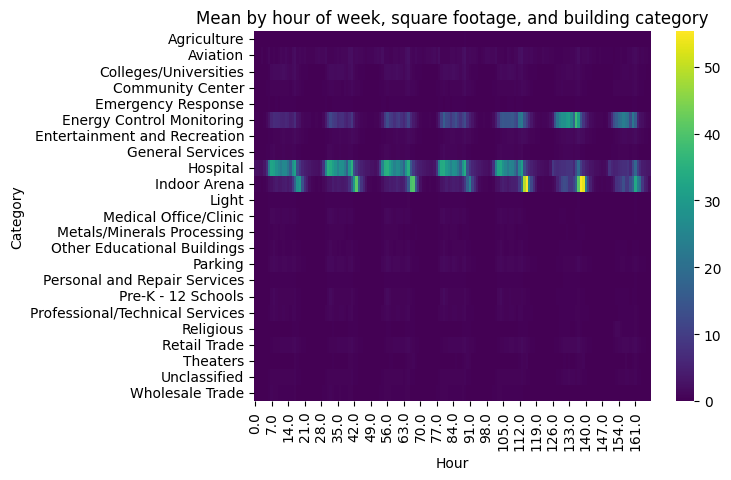

In [10]:
visits_data = group.pivot(index=["t", "sq_q"], columns="prim_occ", values="visits").reset_index().drop('sq_q', axis = 1).groupby('t').agg('mean').transpose()
sns.heatmap(visits_data, cmap="viridis", cbar=True)
# sns.heatmap(visits_data, cmap="viridis", cbar=True, vmax = 20)

plt.xlabel("Hour")
plt.ylabel("Category")
plt.title("Mean by hour of week, square footage, and building category")
plt.show()

In [11]:
test_pred = test.merge(
    group[['t', 'sq_q', 'prim_occ', 'visits']],
    on=['t', 'sq_q', 'prim_occ'],
    how='left',
    suffixes=('', '_pred')
)

In [12]:
test_pred

,build_id,t,occ_cls,prim_occ,sqmeters,sqfeet,censuscode,uuid,safegraph_place_id,date_range_start,visits,sq_q,visits_pred
0,15162,0.0,Commercial,Retail Trade,244.601166,2632.862549,41005021900,{cd7bc626-ad5b-4684-8e00-c771e4f39fd8},sg:cc3046db4edd4008b5fc8c2f381861f2,2018-12-31 08:00:00,0.0,1,0.051400
1,15162,1.0,Commercial,Retail Trade,244.601166,2632.862549,41005021900,{cd7bc626-ad5b-4684-8e00-c771e4f39fd8},sg:cc3046db4edd4008b5fc8c2f381861f2,2018-12-31 08:00:00,0.0,1,0.041565
2,15162,2.0,Commercial,Retail Trade,244.601166,2632.862549,41005021900,{cd7bc626-ad5b-4684-8e00-c771e4f39fd8},sg:cc3046db4edd4008b5fc8c2f381861f2,2018-12-31 08:00:00,0.0,1,0.033654
3,15162,3.0,Commercial,Retail Trade,244.601166,2632.862549,41005021900,{cd7bc626-ad5b-4684-8e00-c771e4f39fd8},sg:cc3046db4edd4008b5fc8c2f381861f2,2018-12-31 08:00:00,0.0,1,0.024888
4,15162,4.0,Commercial,Retail Trade,244.601166,2632.862549,41005021900,{cd7bc626-ad5b-4684-8e00-c771e4f39fd8},sg:cc3046db4edd4008b5fc8c2f381861f2,2018-12-31 08:00:00,0.0,1,0.032499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5026051,8213855,163.0,Education,Pre-K - 12 Schools,3586.792480,38607.875000,41051003802,{2bcec792-d680-4f98-abae-7733af74d23d},sg:89e97202a2ad45ea8055864659beedb0,2019-02-25 08:00:00,0.0,4,0.230131
5026052,8213855,164.0,Education,Pre-K - 12 Schools,3586.792480,38607.875000,41051003802,{2bcec792-d680-4f98-abae-7733af74d23d},sg:89e97202a2ad45ea8055864659beedb0,2019-02-25 08:00:00,0.0,4,0.178254
5026053,8213855,165.0,Education,Pre-K - 12 Schools,3586.792480,38607.875000,41051003802,{2bcec792-d680-4f98-abae-7733af74d23d},sg:89e97202a2ad45ea8055864659beedb0,2019-02-25 08:00:00,0.0,4,0.136028
5026054,8213855,166.0,Education,Pre-K - 12 Schools,3586.792480,38607.875000,41051003802,{2bcec792-d680-4f98-abae-7733af74d23d},sg:89e97202a2ad45ea8055864659beedb0,2019-02-25 08:00:00,0.0,4,0.103906


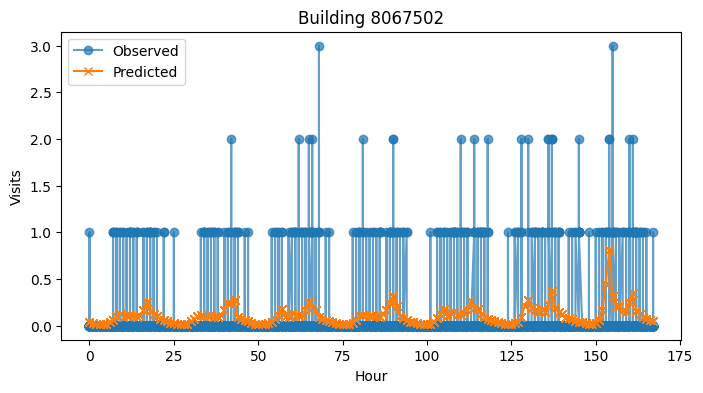

In [14]:
build = np.random.default_rng().choice(test_pred['build_id'].unique())

build_preds = (
    test_pred[test_pred['build_id'] == build]
    .sort_values('t')
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    build_preds['t'],
    build_preds['visits'],
    marker='o',
    alpha=0.7,
    label='Observed'
)

ax.plot(
    build_preds['t'],
    build_preds['visits_pred'],
    marker='x',
    label='Predicted'
)

ax.set(
    xlabel='Hour',
    ylabel='Visits',
    title=f"Building {build}"
)

ax.legend()
plt.show()